# Telco Customer Churn — Pipeline Analisis Data

Notebook ini berisi pipeline analisis **Customer Churn** untuk perusahaan telekomunikasi, terdiri dari 3 tahap utama:

1. **Data Assessing** — memeriksa kualitas data (tipe data, missing values, duplikat, statistik deskriptif).
2. **Data Handling & Cleaning** — membersihkan data (konversi tipe, imputasi, binarisasi target).
3. **Exploratory Data Analysis (EDA)** — menghitung metrik bisnis dan membuat visualisasi.

> **Dataset**: `Telco-Customer-Churn.csv` (dataset publik Telco Customer Churn dari Kaggle/IBM Sample Data).

---
### Daftar Isi
- [0. Setup & Import Library](#0)
- [1. Load Data (Lokal / Google Drive)](#1)
- [2. Tahap 1 — Data Assessing](#2)
- [3. Tahap 2 — Data Handling & Cleaning](#3)
- [4. Tahap 3 — Exploratory Data Analysis (EDA)](#4)
- [5. Kesimpulan & Insight Bisnis](#5)


<a id="0"></a>
## 0. Setup & Import Library

Sel di bawah ini meng-install (bila perlu) dan meng-import seluruh library yang dibutuhkan.

- `pandas`, `numpy` → manipulasi data
- `matplotlib`, `seaborn` → visualisasi
- `gdown` → download file dari Google Drive menggunakan link publik (opsional, hanya diperlukan jika memilih sumber data dari Google Drive link)



In [1]:
# Uncomment baris berikut jika library belum terpasang di environment Anda
# !pip install pandas numpy matplotlib seaborn gdown --quiet

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Konfigurasi tampilan terminal & matplotlib
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = "DejaVu Sans"
plt.rcParams['font.size'] = 10

print("✅ Library berhasil di-import.")

✅ Library berhasil di-import.


<a id="1"></a>
## 1. Load Data (Lokal / Google Drive)

Sel ini menyediakan **3 opsi sumber data**. Pilih salah satu dengan mengubah nilai variabel `DATA_SOURCE` pada sel konfigurasi di bawah:

| Nilai `DATA_SOURCE` | Kapan digunakan | Yang perlu diisi |
|---|---|---|
| `"local"` | File CSV sudah ada di direktori/environment yang sama dengan notebook (default, sesuai script asli) | `LOCAL_FILE_PATH` |
| `"gdrive_mount"` | Menjalankan notebook di **Google Colab** dan file berada di Google Drive Anda | `GDRIVE_FILE_PATH` (path relatif di dalam Drive) |
| `"gdrive_link"` | File berada di Google Drive dan Anda punya **link share publik** (Anyone with the link), dijalankan di Colab maupun lokal | `GDRIVE_SHARE_LINK` |

>


In [2]:
# ==============================================================================
# KONFIGURASI SUMBER DATA — UBAH BAGIAN INI SESUAI KEBUTUHAN ANDA
# ==============================================================================

# Pilih salah satu: "local" | "gdrive_mount" | "gdrive_link"
DATA_SOURCE = "gdrive_mount"

# --- Opsi 1: File lokal (sudah ada di folder yang sama dengan notebook) ---
LOCAL_FILE_PATH = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

# --- Opsi 2: File di Google Drive, dibuka via mount drive (khusus Google Colab) ---
GDRIVE_FILE_PATH = "MyDrive/Portofolio/Telco Churn Analysis/Telco-Customer-Churn.csv"  # path relatif di dalam Drive

# --- Opsi 3: File di Google Drive dengan link share publik ---
# Contoh link: https://drive.google.com/file/d/FILE_ID_DISINI/view?usp=sharing
GDRIVE_SHARE_LINK = "https://drive.google.com/file/d/FILE_ID_DISINI/view?usp=sharing"

print(f"Sumber data yang dipilih: '{DATA_SOURCE}'")

Sumber data yang dipilih: 'gdrive_mount'


In [3]:
# ==============================================================================
# RESOLVE FILE_PATH BERDASARKAN DATA_SOURCE YANG DIPILIH DI ATAS
# ==============================================================================

DATA_FILE = None

if DATA_SOURCE == "local":
    # Menggunakan file yang sudah ada di direktori kerja saat ini
    DATA_FILE = LOCAL_FILE_PATH

elif DATA_SOURCE == "gdrive_mount":
    # Mount Google Drive terlebih dahulu (hanya berjalan di Google Colab)
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        DATA_FILE = os.path.join('/content/drive', GDRIVE_FILE_PATH)
    except ImportError:
        raise RuntimeError(
            "Opsi 'gdrive_mount' hanya bisa dijalankan di Google Colab. "
            "Gunakan 'local' atau 'gdrive_link' jika menjalankan notebook secara lokal."
        )

elif DATA_SOURCE == "gdrive_link":
    # Download file dari Google Drive menggunakan link share publik via gdown
    import gdown

    # Ekstrak FILE_ID dari link Google Drive
    if "/d/" in GDRIVE_SHARE_LINK:
        file_id = GDRIVE_SHARE_LINK.split("/d/")[1].split("/")[0]
    else:
        raise ValueError("Format GDRIVE_SHARE_LINK tidak dikenali. Gunakan link berformat '.../d/FILE_ID/view'.")

    DATA_FILE = "Telco-Customer-Churn.csv"
    gdown.download(id=file_id, output=DATA_FILE, quiet=False)

else:
    raise ValueError("DATA_SOURCE harus salah satu dari: 'local', 'gdrive_mount', 'gdrive_link'.")

# Validasi apakah file berhasil ditemukan
if os.path.exists(DATA_FILE):
    print(f"✅ Data ditemukan: '{DATA_FILE}'")
else:
    print(f"❌ File '{DATA_FILE}' tidak ditemukan. Silakan periksa kembali konfigurasi DATA_SOURCE di atas, "
          f"atau unduh dataset dari Kaggle terlebih dahulu.")

Mounted at /content/drive
✅ Data ditemukan: '/content/drive/MyDrive/Portofolio/Telco Churn Analysis/Telco-Customer-Churn.csv'


<a id="2"></a>
## 2. Tahap 1 — Data Assessing

Tahap ini bertujuan untuk memahami kondisi awal data **sebelum** dilakukan pembersihan, meliputi:
- Dimensi dataset (jumlah baris & kolom)
- Tipe data dan jumlah missing value per kolom
- Baris duplikat
- Deteksi *hidden missing values* (nilai berupa spasi kosong `' '`)
- Statistik deskriptif untuk kolom numerik


In [4]:
# Load dataset mentah (raw) dari file yang sudah ditentukan pada tahap sebelumnya
df_raw = pd.read_csv(DATA_FILE)

print(f"Baris: {df_raw.shape[0]} | Kolom: {df_raw.shape[1]}")
df_raw.head()

Baris: 7043 | Kolom: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 2.1 Informasi Kolom & Tipe Data
Memeriksa tipe data setiap kolom beserta jumlah dan persentase *missing value*-nya.

In [5]:
info_df = pd.DataFrame({
    'Data Type': df_raw.dtypes,
    'Null Count': df_raw.isnull().sum(),
    'Null Percentage (%)': (df_raw.isnull().sum() / len(df_raw)) * 100
})
info_df

,Data Type,Null Count,Null Percentage (%)
customerID,object,0,0.0
gender,object,0,0.0
SeniorCitizen,int64,0,0.0
Partner,object,0,0.0
Dependents,object,0,0.0
tenure,int64,0,0.0
PhoneService,object,0,0.0
MultipleLines,object,0,0.0
InternetService,object,0,0.0
OnlineSecurity,object,0,0.0


### 2.2 Baris Duplikat
Mengecek apakah ada baris yang benar-benar identik di seluruh kolom.

In [6]:
jumlah_duplikat = df_raw.duplicated().sum()
print(f"Jumlah Baris Duplikat: {jumlah_duplikat}")

Jumlah Baris Duplikat: 0


### 2.3 Deteksi *Hidden Missing Values* (Spasi Kosong)

Pada dataset Telco Churn, kolom `TotalCharges` sering menyimpan nilai kosong dalam bentuk string spasi (`' '`) alih-alih `NaN`, sehingga tidak terdeteksi oleh `isnull()` biasa. Sel ini memeriksa seluruh kolom bertipe teks untuk kasus semacam ini.


In [7]:
hidden_nulls = {}
for col in df_raw.columns:
    if df_raw[col].dtype == 'object':
        empty_spaces = df_raw[col].astype(str).str.strip().eq('').sum()
        if empty_spaces > 0:
            hidden_nulls[col] = empty_spaces

if hidden_nulls:
    for col, count in hidden_nulls.items():
        print(f"⚠️ Kolom '{col}' memiliki {count} nilai berupa spasi kosong (' ')!")
else:
    print("TIDAK ditemukan nilai spasi kosong.")

⚠️ Kolom 'TotalCharges' memiliki 11 nilai berupa spasi kosong (' ')!


### 2.4 Statistik Deskriptif (Numerik)
Menampilkan ringkasan statistik (mean, std, min, max, dsb.) untuk kolom-kolom numerik.

In [8]:
df_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


<a id="3"></a>
## 3. Tahap 2 — Data Handling & Cleaning

Berdasarkan temuan pada tahap *assessing*, dilakukan langkah-langkah pembersihan berikut:
1. Konversi kolom `TotalCharges` dari teks ke numerik + imputasi nilai kosong.
2. Menghapus baris duplikat (jika ada).
3. Membuat kolom target biner `Churn_Numeric` (Yes → 1, No → 0).
4. Menghapus kolom `customerID` (tidak relevan untuk analisis/modeling).
5. Menyimpan hasil data bersih ke file CSV baru.


In [9]:
# Membuat salinan data agar df_raw (data mentah) tetap utuh sebagai arsip/pembanding
df_clean = df_raw.copy()
print("Salinan data untuk proses cleaning telah dibuat: 'df_clean'")

Salinan data untuk proses cleaning telah dibuat: 'df_clean'


### 3.1 Membersihkan Kolom `TotalCharges`

Kolom ini awalnya bertipe teks (object) karena mengandung spasi kosong. Berikut langkahnya:
1. Ubah spasi kosong menjadi `NaN`.
2. Konversi tipe data ke numerik (`float`).
3. Isi (impute) nilai `NaN` dengan `0.0`, dengan asumsi nilai kosong tersebut berasal dari pelanggan baru (`tenure = 0`) yang belum memiliki tagihan total.


In [10]:
df_clean['TotalCharges'] = df_clean['TotalCharges'].astype(str).str.strip().replace('', np.nan)
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'])

nan_count = df_clean['TotalCharges'].isnull().sum()
print(f"Ditemukan {nan_count} NaN setelah konversi ke numerik.")

Ditemukan 11 NaN setelah konversi ke numerik.


In [11]:
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(0.0)
print("Imputasi NaN pada 'TotalCharges' dengan 0.0 (asumsi pelanggan baru / tenure = 0) selesai.")

Imputasi NaN pada 'TotalCharges' dengan 0.0 (asumsi pelanggan baru / tenure = 0) selesai.


### 3.2 Menghapus Baris Duplikat
(Jika ditemukan pada tahap assessing sebelumnya)

In [12]:
if df_clean.duplicated().sum() > 0:
    df_clean = df_clean.drop_duplicates()
    print("Baris duplikat berhasil dibersihkan.")
else:
    print("Tidak ada baris duplikat.")

Tidak ada baris duplikat.


### 3.3 Membuat Kolom Target Biner `Churn_Numeric`

Kolom `Churn` asli berupa teks (`'Yes'` / `'No'`). Untuk keperluan analisis kuantitatif dan modeling, dibuat kolom numerik: `Yes` → `1`, `No` → `0`.


In [13]:
df_clean['Churn_Numeric'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})
df_clean[['Churn', 'Churn_Numeric']].head()

,Churn,Churn_Numeric
0,No,0
1,No,0
2,Yes,1
3,No,0
4,Yes,1


### 3.4 Menghapus Kolom `customerID`
Kolom ini hanya berupa identifier unik dan tidak memiliki nilai prediktif/analitis.

In [14]:
if 'customerID' in df_clean.columns:
    df_clean = df_clean.drop(columns=['customerID'])
    print("Kolom 'customerID' berhasil dihapus.")

Kolom 'customerID' berhasil dihapus.


### 3.5 Menyimpan Data Bersih
Data yang sudah bersih disimpan ke file CSV baru agar bisa digunakan kembali tanpa mengulang proses cleaning.

In [15]:
df_clean.to_csv('telco_churn_cleaned.csv', index=False)

print("✅ Pembersihan Data Selesai!")
print(f"Ukuran Data Akhir: {df_clean.shape[0]} Baris, {df_clean.shape[1]} Kolom")
print("File bersih disimpan ke: 'telco_churn_cleaned.csv'")

✅ Pembersihan Data Selesai!
Ukuran Data Akhir: 7043 Baris, 21 Kolom
File bersih disimpan ke: 'telco_churn_cleaned.csv'


<a id="4"></a>
## 4. Tahap 3 — Exploratory Data Analysis (EDA)

Pada tahap ini dilakukan:
- Perhitungan metrik bisnis utama (KPI) terkait churn.
- Visualisasi churn rate berdasarkan jenis kontrak & layanan internet.
- Visualisasi distribusi tenure dan biaya bulanan terhadap status churn.
- Visualisasi matriks korelasi antar variabel numerik.


### 4.1 Metrik Bisnis Utama (KPI)

In [16]:
total_customers = len(df_clean)
total_churned = df_clean['Churn_Numeric'].sum()
churn_rate = (total_churned / total_customers) * 100
total_mrr = df_clean['MonthlyCharges'].sum()
mrr_lost = df_clean[df_clean['Churn'] == 'Yes']['MonthlyCharges'].sum()

print("📊 OVERALL BUSINESS METRICS:")
print(f"• Total Pelanggan              : {total_customers:,}")
print(f"• Pelanggan Churn              : {total_churned:,}")
print(f"• Overall Churn Rate           : {churn_rate:.2f}%")
print(f"• Total Pendapatan Bulanan     : ${total_mrr:,.2f}")
print(f"• Pendapatan Hilang (MRR Lost) : ${mrr_lost:,.2f} ({(mrr_lost/total_mrr)*100:.2f}% dari total MRR)")

📊 OVERALL BUSINESS METRICS:
• Total Pelanggan              : 7,043
• Pelanggan Churn              : 1,869
• Overall Churn Rate           : 26.54%
• Total Pendapatan Bulanan     : $456,116.60
• Pendapatan Hilang (MRR Lost) : $139,130.85 (30.50% dari total MRR)


### 4.2 Churn Rate berdasarkan Jenis Kontrak & Layanan Internet

Visualisasi ini membantu mengidentifikasi segmen pelanggan mana (jenis kontrak / jenis layanan internet) yang memiliki risiko churn tertinggi.


/tmp/ipykernel_502/299210287.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=contract_churn, x='Contract', y='Churn_Numeric', ax=axes[0],
/tmp/ipykernel_502/299210287.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=internet_churn, x='InternetService', y='Churn_Numeric', ax=axes[1],


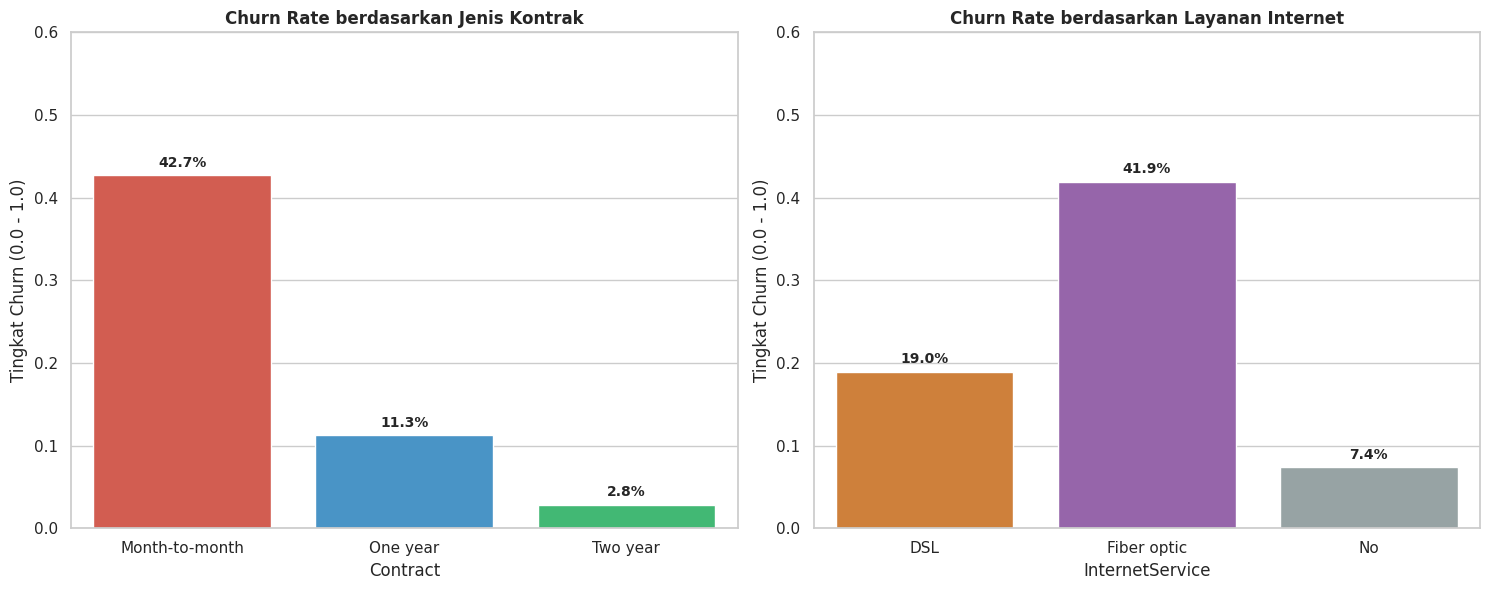

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Churn rate berdasarkan jenis kontrak ---
contract_churn = df_clean.groupby('Contract')['Churn_Numeric'].mean().reset_index()
sns.barplot(data=contract_churn, x='Contract', y='Churn_Numeric', ax=axes[0],
            palette=['#e74c3c', '#3498db', '#2ecc71'])
axes[0].set_title('Churn Rate berdasarkan Jenis Kontrak', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Tingkat Churn (0.0 - 1.0)')
axes[0].set_ylim(0, 0.6)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height()*100:.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                      ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontweight='bold')

# --- Churn rate berdasarkan jenis layanan internet ---
internet_churn = df_clean.groupby('InternetService')['Churn_Numeric'].mean().reset_index()
sns.barplot(data=internet_churn, x='InternetService', y='Churn_Numeric', ax=axes[1],
            palette=['#e67e22', '#9b59b6', '#95a5a6'])
axes[1].set_title('Churn Rate berdasarkan Layanan Internet', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Tingkat Churn (0.0 - 1.0)')
axes[1].set_ylim(0, 0.6)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height()*100:.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                      ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_contract_internet_churn.png', dpi=300)
plt.show()

### 4.3 Distribusi Tenure & Biaya Bulanan terhadap Status Churn

- **Kiri**: Distribusi lamanya berlangganan (tenure) dipisahkan berdasarkan status churn.
- **Kanan**: Sebaran biaya bulanan (MonthlyCharges) dibandingkan antara pelanggan yang churn dan tidak.


/tmp/ipykernel_502/3862517592.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Churn', y='MonthlyCharges',


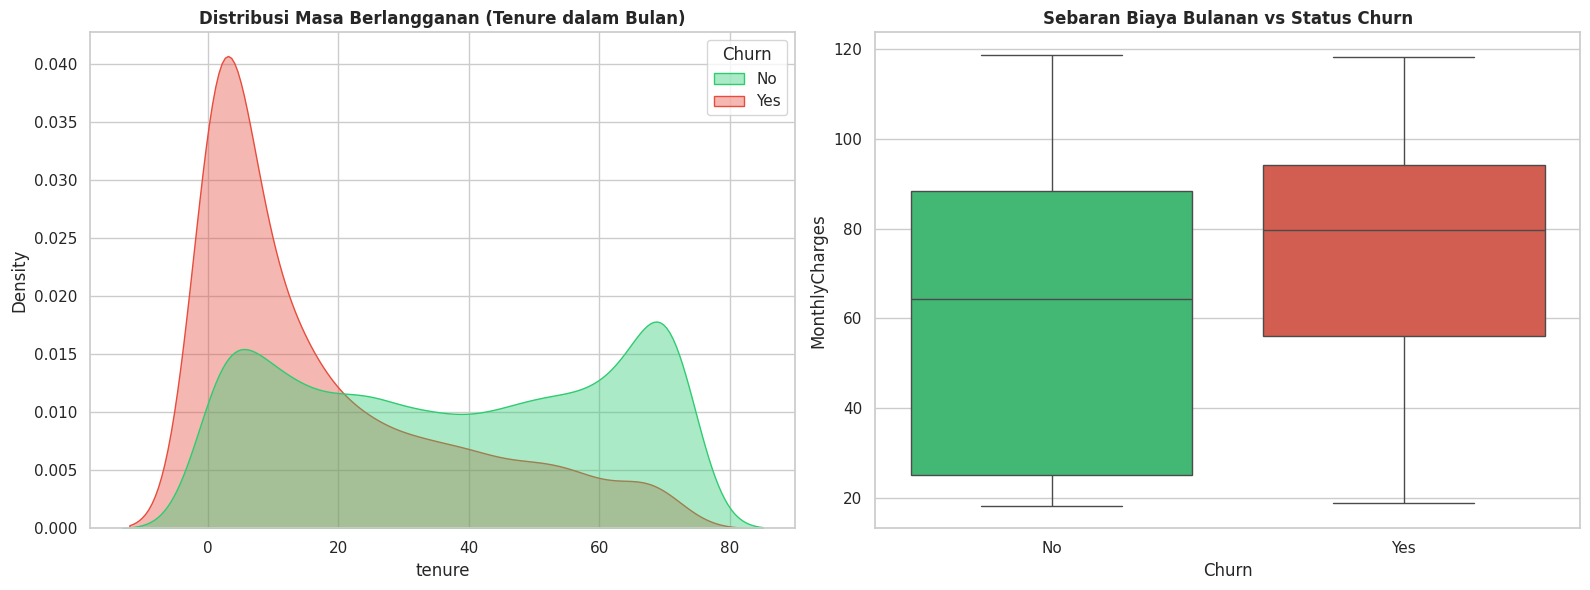

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.kdeplot(data=df_clean, x='tenure', hue='Churn', common_norm=False, fill=True,
            palette={'Yes': '#e74c3c', 'No': '#2ecc71'}, ax=axes[0], alpha=0.4)
axes[0].set_title('Distribusi Masa Berlangganan (Tenure dalam Bulan)', fontsize=12, fontweight='bold')

sns.boxplot(data=df_clean, x='Churn', y='MonthlyCharges',
            palette={'Yes': '#e74c3c', 'No': '#2ecc71'}, ax=axes[1])
axes[1].set_title('Sebaran Biaya Bulanan vs Status Churn', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_tenure_monthly_charges.png', dpi=300)
plt.show()

### 4.4 Matriks Korelasi Variabel Numerik
Menunjukkan kekuatan hubungan linear antar variabel numerik, termasuk terhadap `Churn_Numeric`.

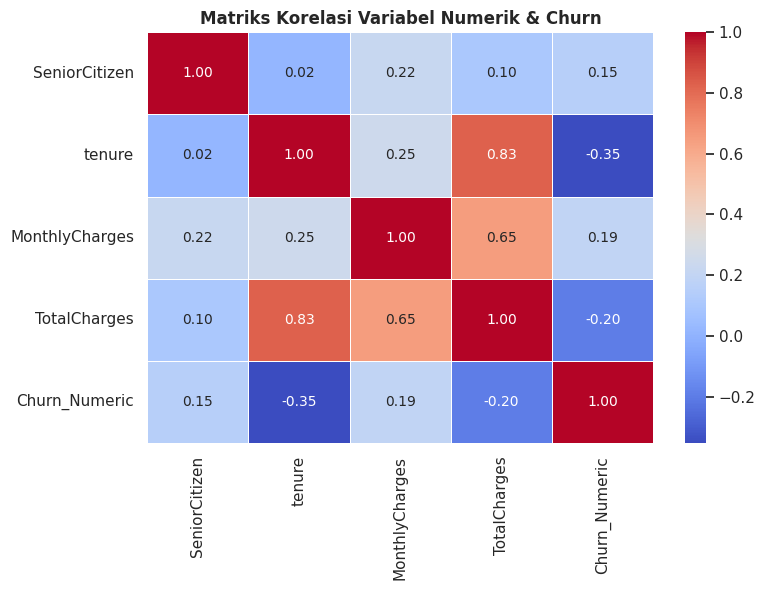

In [19]:
numeric_df = df_clean.select_dtypes(include=[np.number])

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriks Korelasi Variabel Numerik & Churn', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation_matrix.png', dpi=300)
plt.show()

### 4.5 Analisis Mendalam — Mencari Variabel Lain yang Memengaruhi Churn

Bagian sebelumnya (4.2–4.4) hanya menyoroti **Contract**, **InternetService**, **tenure**, dan **MonthlyCharges**. Pada bagian ini dilakukan eksplorasi yang lebih sistematis terhadap **seluruh variabel kategorikal** di dataset untuk menemukan variabel lain yang berpotensi memengaruhi churn, dengan pendekatan:

1. **Ranking otomatis** seluruh variabel kategorikal berdasarkan besar selisih (*range*) churn rate antar kategorinya.
2. **Uji statistik Chi-Square** untuk mengetahui variabel mana yang asosiasinya dengan churn signifikan secara statistik (bukan kebetulan).
3. **Visualisasi mendalam** per kelompok variabel: demografi, layanan tambahan (*add-on services*), dan metode pembayaran/tagihan.
4. **Ranking korelasi numerik** terhadap `Churn_Numeric`.


#### 4.5.1 Ranking Otomatis Seluruh Variabel Kategorikal

Sel di bawah ini secara otomatis mengambil **semua kolom kategorikal** (kecuali `Churn` itu sendiri), menghitung churn rate per kategori, lalu mengurutkan variabel berdasarkan **selisih churn rate terbesar** (`max - min`) antar kategorinya. Semakin besar selisihnya, semakin besar potensi variabel tersebut sebagai pembeda (*differentiator*) antara pelanggan yang churn dan tidak.


In [20]:
# Ambil seluruh kolom kategorikal (object), kecuali kolom target 'Churn'
cat_cols = [c for c in df_clean.select_dtypes(include='object').columns if c != 'Churn']

summary_rows = []
for col in cat_cols:
    rate_per_kategori = df_clean.groupby(col)['Churn_Numeric'].mean()
    summary_rows.append({
        'Variabel': col,
        'Jumlah Kategori': df_clean[col].nunique(),
        'Churn Rate Min (%)': rate_per_kategori.min() * 100,
        'Churn Rate Max (%)': rate_per_kategori.max() * 100,
        'Selisih (Range) (%)': (rate_per_kategori.max() - rate_per_kategori.min()) * 100,
        'Kategori dgn Churn Tertinggi': rate_per_kategori.idxmax()
    })

ranking_df = pd.DataFrame(summary_rows).sort_values('Selisih (Range) (%)', ascending=False).reset_index(drop=True)
ranking_df

,Variabel,Jumlah Kategori,Churn Rate Min (%),Churn Rate Max (%),Selisih (Range) (%),Kategori dgn Churn Tertinggi
0,Contract,3,2.831858,42.709677,39.877819,Month-to-month
1,InternetService,3,7.404980,41.892765,34.487785,Fiber optic
2,OnlineSecurity,3,7.404980,41.766724,34.361744,No
3,TechSupport,3,7.404980,41.635474,34.230493,No
4,OnlineBackup,3,7.404980,39.928756,32.523776,No
5,DeviceProtection,3,7.404980,39.127625,31.722645,No
6,PaymentMethod,4,15.243101,45.285412,30.042311,Electronic check
7,StreamingMovies,3,7.404980,33.680431,26.275451,No
8,StreamingTV,3,7.404980,33.523132,26.118151,No
9,PaperlessBilling,2,16.330084,33.565092,17.235009,Yes


> 📌 **Cara membaca tabel di atas**: variabel yang berada di baris paling atas adalah variabel dengan **selisih churn rate antar kategori paling besar** — artinya variabel tersebut kemungkinan besar merupakan faktor pembeda yang kuat terhadap churn, di luar `Contract` dan `InternetService` yang sudah dibahas sebelumnya.

#### 4.5.2 Uji Signifikansi Statistik (Chi-Square Test)

Selisih churn rate yang besar belum tentu signifikan secara statistik, terutama jika jumlah data di salah satu kategori sedikit. Untuk memastikan asosiasi antara tiap variabel kategorikal dengan `Churn` bukan hasil kebetulan, dilakukan **Chi-Square Test of Independence**.

- **H0 (hipotesis nol)**: variabel tidak berhubungan dengan churn.
- Jika **p-value < 0.05**, maka H0 ditolak → variabel tersebut **signifikan secara statistik** berhubungan dengan churn.


In [21]:
from scipy.stats import chi2_contingency

chi_results = []
for col in cat_cols:
    kontingensi = pd.crosstab(df_clean[col], df_clean['Churn'])
    chi2, p_value, dof, expected = chi2_contingency(kontingensi)
    chi_results.append({
        'Variabel': col,
        'Chi2 Statistic': chi2,
        'p-value': p_value,
        'Signifikan (p < 0.05)?': 'Ya ✅' if p_value < 0.05 else 'Tidak ❌'
    })

chi_df = pd.DataFrame(chi_results).sort_values('p-value').reset_index(drop=True)
chi_df

,Variabel,Chi2 Statistic,p-value,Signifikan (p < 0.05)?
0,Contract,1184.596572,5.863038e-258,Ya ✅
1,OnlineSecurity,849.998968,2.661150e-185,Ya ✅
2,TechSupport,828.197068,1.443084e-180,Ya ✅
3,InternetService,732.309590,9.571788e-160,Ya ✅
4,PaymentMethod,648.142327,3.682355e-140,Ya ✅
5,OnlineBackup,601.812790,2.079759e-131,Ya ✅
6,DeviceProtection,558.419369,5.505219e-122,Ya ✅
7,StreamingMovies,375.661479,2.667757e-82,Ya ✅
8,StreamingTV,374.203943,5.528994e-82,Ya ✅
9,PaperlessBilling,258.277649,4.073355e-58,Ya ✅


> 📌 Gabungkan hasil tabel **ranking selisih churn rate** (4.5.1) dengan tabel **signifikansi statistik** (4.5.2) di atas untuk memprioritaskan variabel mana yang paling layak ditindaklanjuti secara bisnis: variabel dengan selisih besar **dan** p-value kecil adalah kandidat paling kuat sebagai pendorong churn.

#### 4.5.3 Visualisasi Variabel dengan Pengaruh Terbesar terhadap Churn

Menampilkan churn rate per kategori untuk **6 variabel teratas** hasil ranking pada bagian 4.5.1, agar pola perbedaannya terlihat jelas secara visual.


/tmp/ipykernel_502/878256800.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rate_per_kategori, x=col, y='Churn_Numeric', ax=axes[i], palette='rocket')
/tmp/ipykernel_502/878256800.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rate_per_kategori, x=col, y='Churn_Numeric', ax=axes[i], palette='rocket')
/tmp/ipykernel_502/878256800.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rate_per_kategori, x=col, y='Churn_Numeric', ax=axes[i], palette='rocket')
/tmp/ipykernel_502/878256800.py:8: FutureWarning: 

Passing `pal

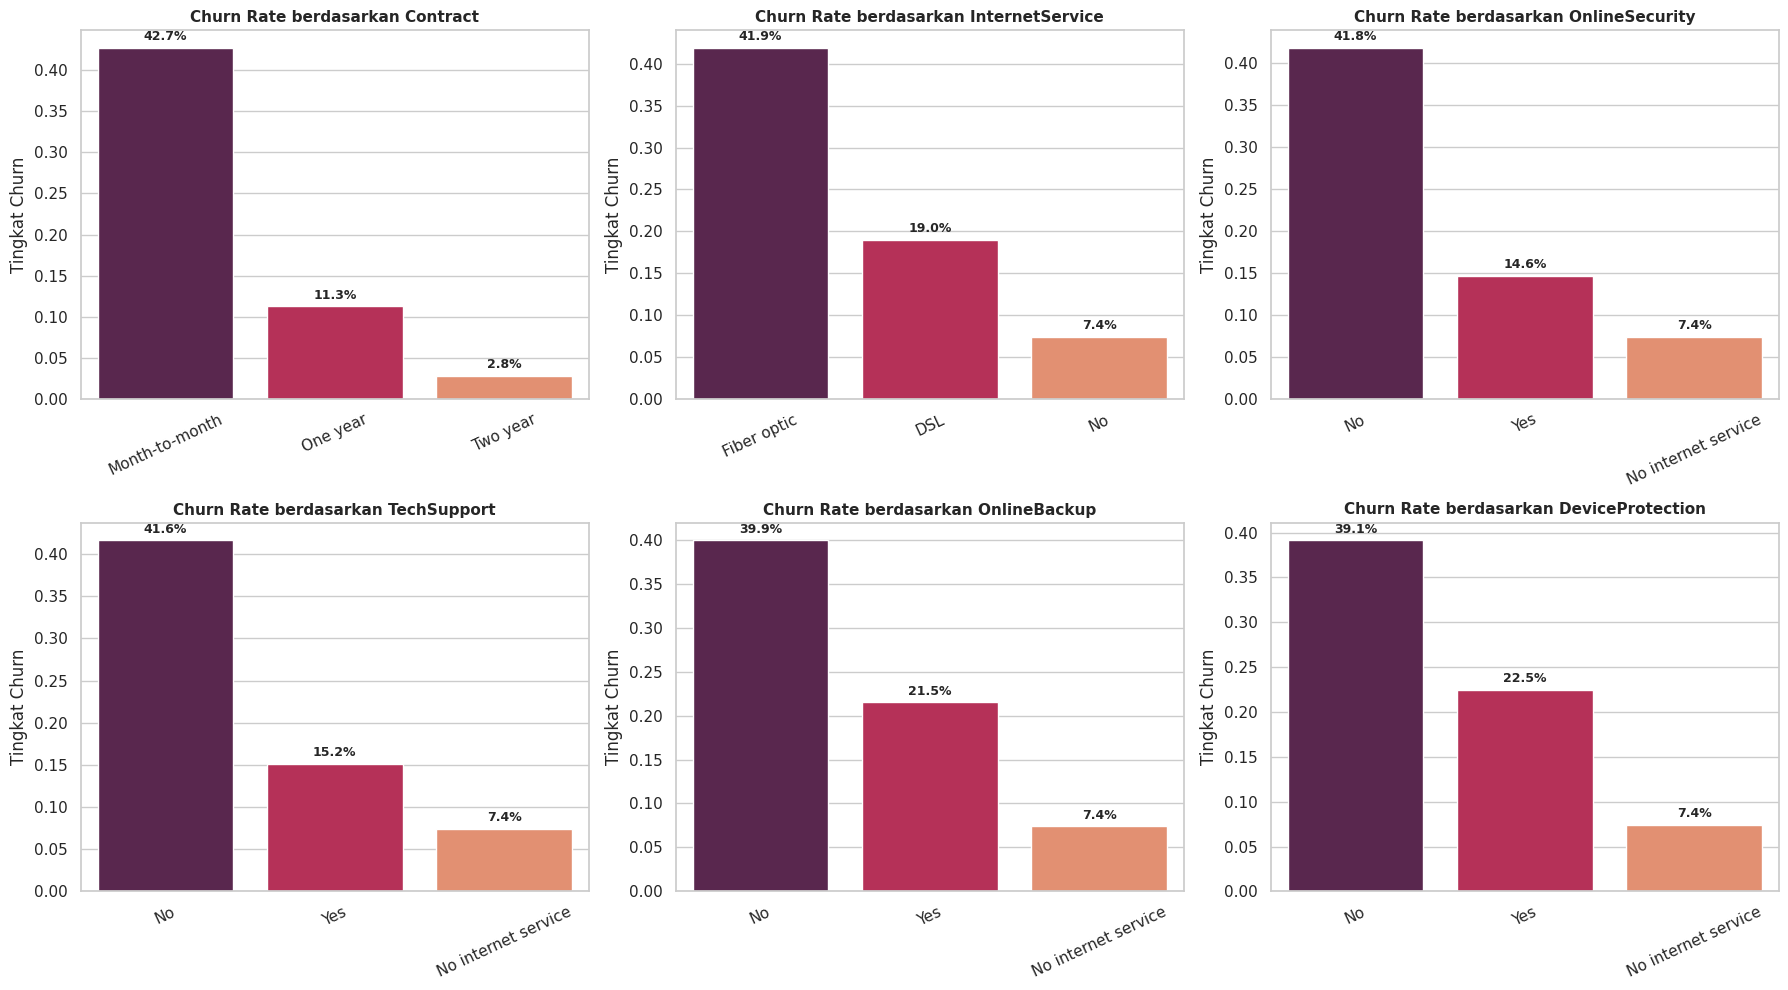

In [22]:
top_vars = ranking_df['Variabel'].head(6).tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(top_vars):
    rate_per_kategori = df_clean.groupby(col)['Churn_Numeric'].mean().sort_values(ascending=False).reset_index()
    sns.barplot(data=rate_per_kategori, x=col, y='Churn_Numeric', ax=axes[i], palette='rocket')
    axes[i].set_title(f'Churn Rate berdasarkan {col}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Tingkat Churn')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=25)
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height()*100:.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                          ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_top_variabel_churn.png', dpi=300)
plt.show()

#### 4.5.4 Faktor Demografi: `gender`, `SeniorCitizen`, `Partner`, `Dependents`

Memeriksa apakah karakteristik demografi pelanggan (jenis kelamin, status lansia, status pasangan, status tanggungan) berhubungan dengan churn.


/tmp/ipykernel_502/3333490736.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rate_per_kategori, x=col, y='Churn_Numeric', ax=axes[i], palette='crest')
/tmp/ipykernel_502/3333490736.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rate_per_kategori, x=col, y='Churn_Numeric', ax=axes[i], palette='crest')
/tmp/ipykernel_502/3333490736.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rate_per_kategori, x=col, y='Churn_Numeric', ax=axes[i], palette='crest')
/tmp/ipykernel_502/3333490736.py:6: FutureWarning: 

Passing `pa

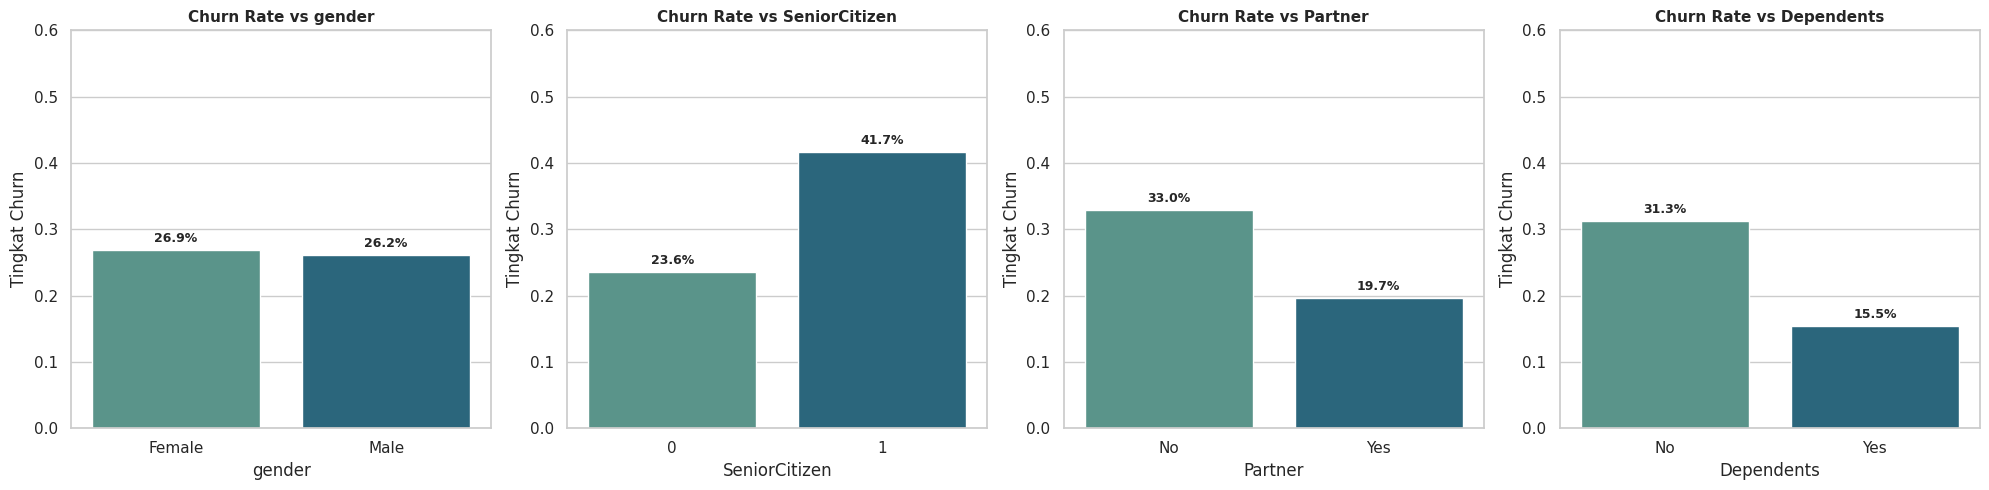

In [23]:
demografi_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, col in enumerate(demografi_cols):
    rate_per_kategori = df_clean.groupby(col)['Churn_Numeric'].mean().reset_index()
    sns.barplot(data=rate_per_kategori, x=col, y='Churn_Numeric', ax=axes[i], palette='crest')
    axes[i].set_title(f'Churn Rate vs {col}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Tingkat Churn')
    axes[i].set_ylim(0, 0.6)
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height()*100:.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                          ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_demografi_churn.png', dpi=300)
plt.show()

#### 4.5.5 Layanan Tambahan (*Add-on Services*)

Memeriksa apakah pelanggan yang **tidak berlangganan layanan proteksi/dukungan** (misalnya `OnlineSecurity`, `TechSupport`) cenderung lebih mudah churn dibandingkan yang berlangganan — insight yang umum ditemukan pada dataset ini dan relevan untuk strategi *up-sell* atau retensi.


/tmp/ipykernel_502/4262255491.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rate_per_kategori, x=col, y='Churn_Numeric', ax=axes[i], palette='flare')
/tmp/ipykernel_502/4262255491.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rate_per_kategori, x=col, y='Churn_Numeric', ax=axes[i], palette='flare')
/tmp/ipykernel_502/4262255491.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rate_per_kategori, x=col, y='Churn_Numeric', ax=axes[i], palette='flare')
/tmp/ipykernel_502/4262255491.py:9: FutureWarning: 

Passing `pa

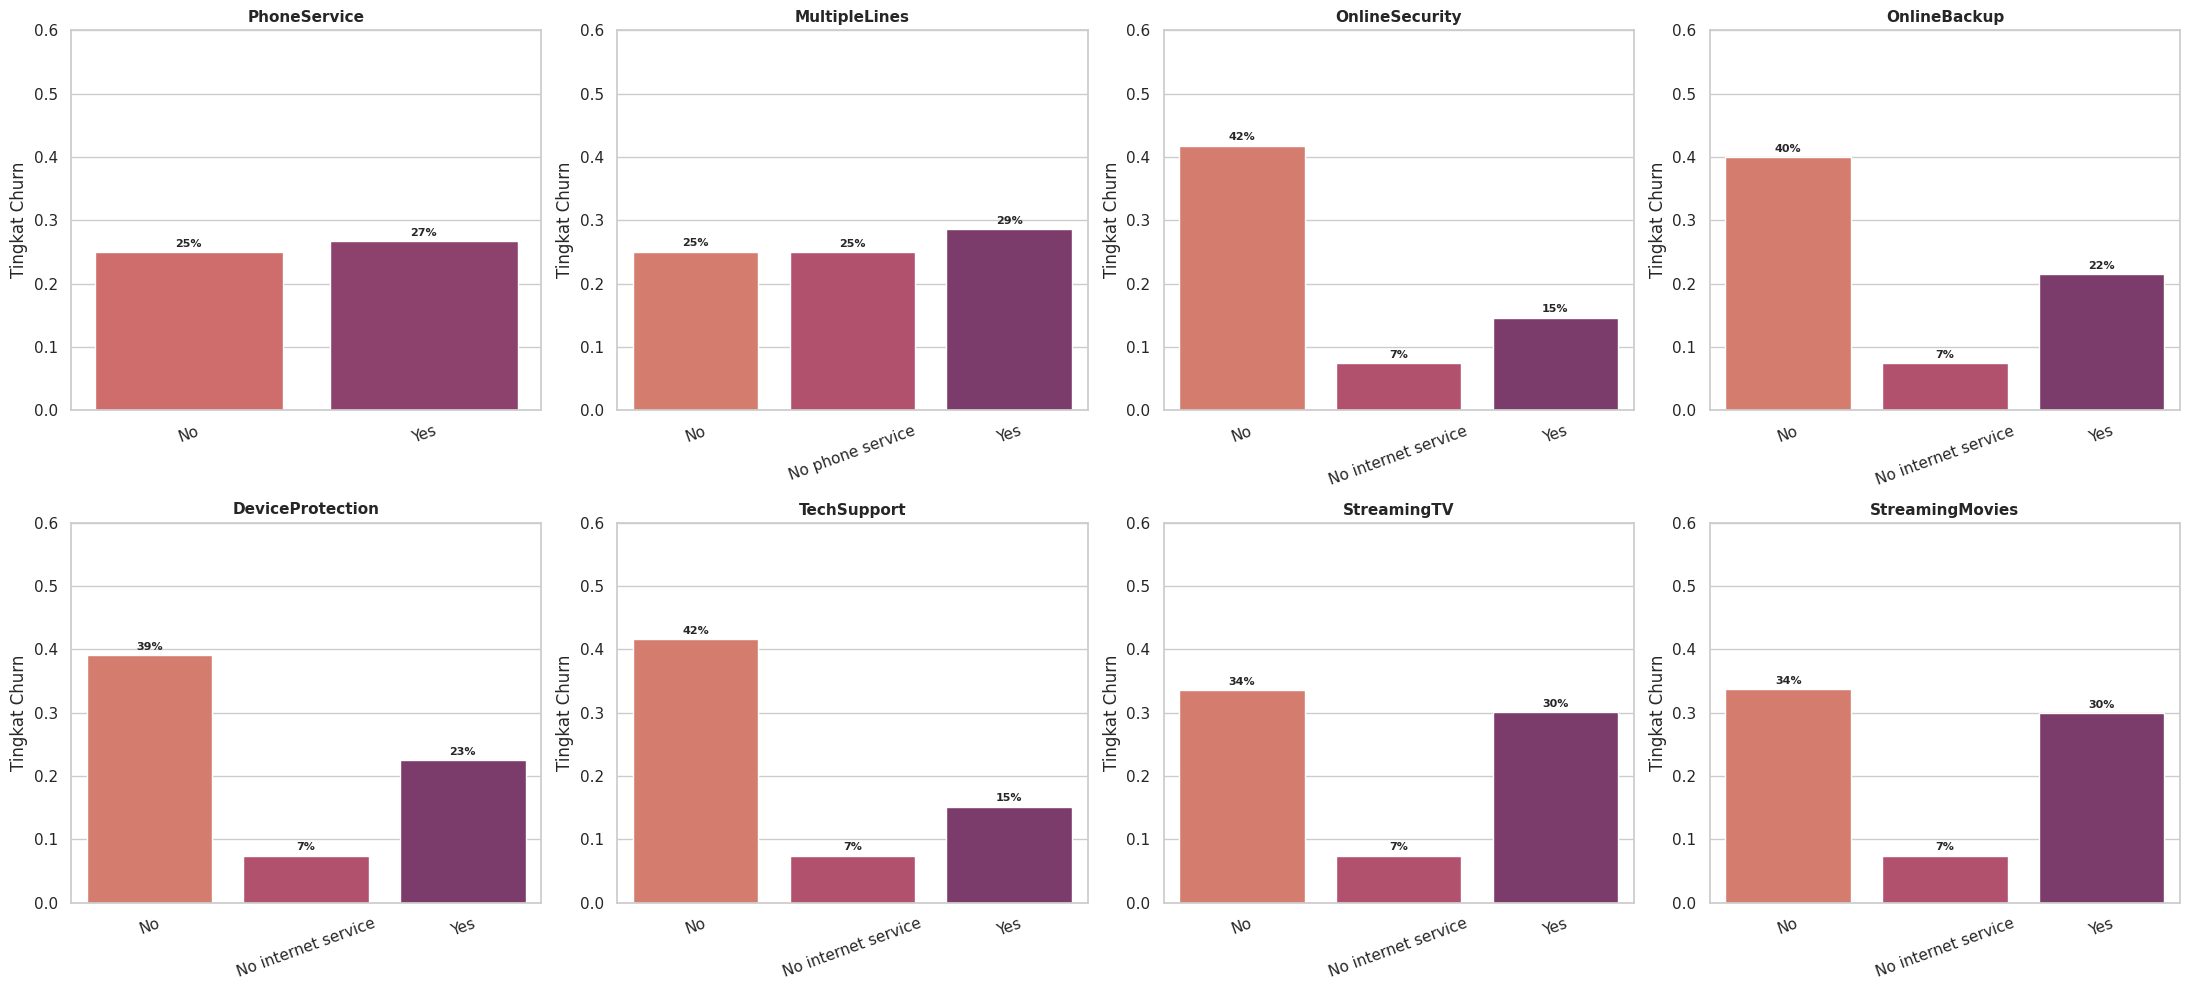

In [24]:
service_cols = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, col in enumerate(service_cols):
    rate_per_kategori = df_clean.groupby(col)['Churn_Numeric'].mean().reset_index()
    sns.barplot(data=rate_per_kategori, x=col, y='Churn_Numeric', ax=axes[i], palette='flare')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Tingkat Churn')
    axes[i].set_xlabel('')
    axes[i].set_ylim(0, 0.6)
    axes[i].tick_params(axis='x', rotation=20)
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height()*100:.0f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                          ha='center', va='center', xytext=(0, 6), textcoords='offset points', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_addon_services_churn.png', dpi=300)
plt.show()

#### 4.5.6 Metode Pembayaran & Jenis Tagihan

Memeriksa apakah cara pelanggan membayar (`PaymentMethod`) dan jenis tagihan (`PaperlessBilling`) berhubungan dengan churn — sering kali metode pembayaran otomatis (*automatic payment*) berasosiasi dengan churn yang lebih rendah dibanding pembayaran manual.


/tmp/ipykernel_502/1256561519.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=payment_churn, x='Churn_Numeric', y='PaymentMethod', ax=axes[0], palette='mako', orient='h')
/tmp/ipykernel_502/1256561519.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=billing_churn, x='PaperlessBilling', y='Churn_Numeric', ax=axes[1], palette=['#3498db', '#e74c3c'])


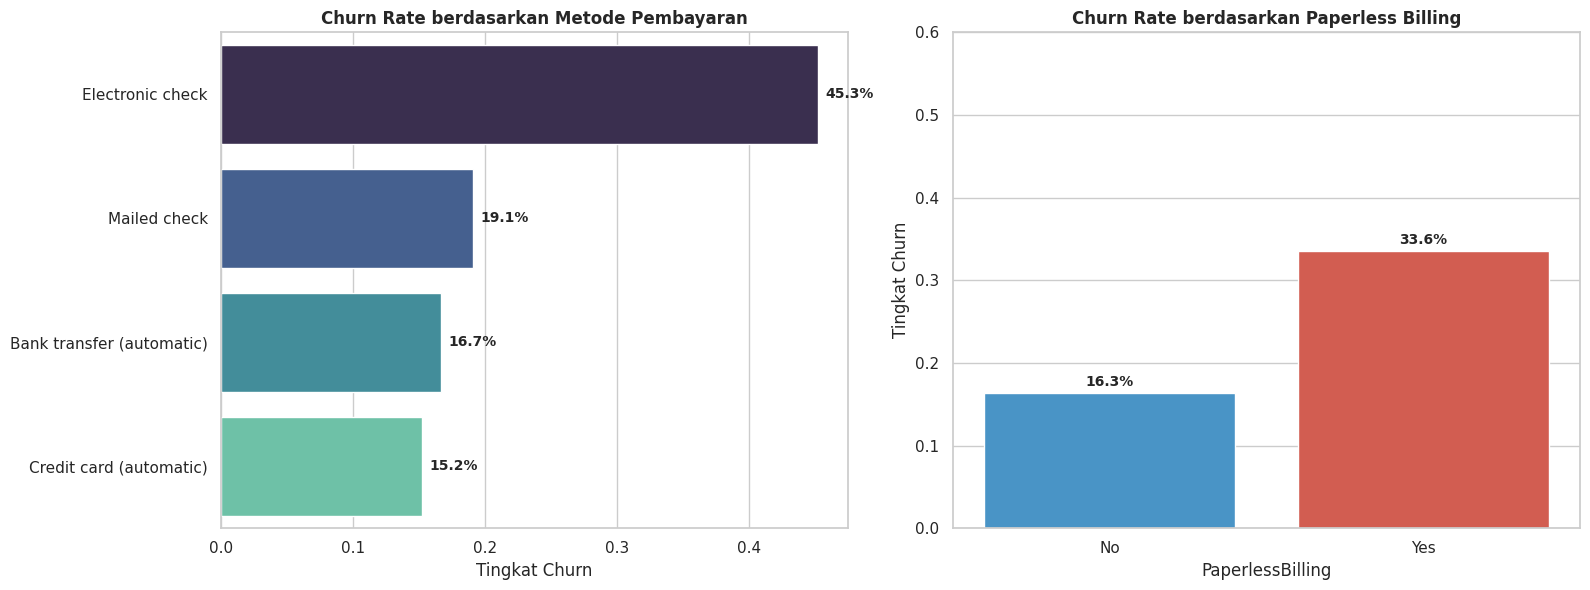

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

payment_churn = df_clean.groupby('PaymentMethod')['Churn_Numeric'].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=payment_churn, x='Churn_Numeric', y='PaymentMethod', ax=axes[0], palette='mako', orient='h')
axes[0].set_title('Churn Rate berdasarkan Metode Pembayaran', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tingkat Churn')
axes[0].set_ylabel('')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_width()*100:.1f}%', (p.get_width(), p.get_y() + p.get_height() / 2.),
                      ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontweight='bold')

billing_churn = df_clean.groupby('PaperlessBilling')['Churn_Numeric'].mean().reset_index()
sns.barplot(data=billing_churn, x='PaperlessBilling', y='Churn_Numeric', ax=axes[1], palette=['#3498db', '#e74c3c'])
axes[1].set_title('Churn Rate berdasarkan Paperless Billing', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Tingkat Churn')
axes[1].set_ylim(0, 0.6)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height()*100:.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                      ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_payment_billing_churn.png', dpi=300)
plt.show()

#### 4.5.7 Ranking Korelasi Variabel Numerik terhadap Churn

Selain variabel kategorikal, berikut ranking eksplisit kekuatan korelasi (Pearson) antara variabel numerik (`tenure`, `MonthlyCharges`, `TotalCharges`) dengan `Churn_Numeric`, diurutkan dari yang paling berpengaruh.


In [26]:
corr_dengan_churn = numeric_df.corr()['Churn_Numeric'].drop('Churn_Numeric').sort_values(key=abs, ascending=False)

corr_ranking_df = corr_dengan_churn.reset_index()
corr_ranking_df.columns = ['Variabel', 'Korelasi dengan Churn']
corr_ranking_df

,Variabel,Korelasi dengan Churn
0,tenure,-0.352229
1,TotalCharges,-0.198324
2,MonthlyCharges,0.193356
3,SeniorCitizen,0.150889


> 📌 Nilai korelasi negatif (misalnya pada `tenure`) berarti semakin **besar** nilai variabel tersebut, semakin **kecil** kemungkinan pelanggan churn — dan sebaliknya untuk korelasi positif.

#### 4.5.8 Ringkasan Temuan Analisis Mendalam

Berdasarkan kombinasi ranking selisih churn rate (4.5.1), uji Chi-Square (4.5.2), dan visualisasi (4.5.3–4.5.6), variabel-variabel berikut umumnya muncul sebagai **faktor tambahan yang signifikan** memengaruhi churn di luar `Contract` dan `InternetService`:

- **`OnlineSecurity`, `TechSupport`, `OnlineBackup`, `DeviceProtection`** — pelanggan yang **tidak** memiliki layanan proteksi/dukungan ini cenderung memiliki churn rate jauh lebih tinggi. Ini adalah peluang *up-sell* sekaligus strategi retensi.
- **`PaymentMethod`** — pelanggan dengan metode **Electronic check** biasanya memiliki churn rate tertinggi dibanding metode pembayaran otomatis (kartu kredit/bank transfer otomatis).
- **`SeniorCitizen`** — pelanggan lansia cenderung memiliki churn rate lebih tinggi dibanding non-lansia.
- **`Partner`** dan **`Dependents`** — pelanggan tanpa pasangan/tanggungan cenderung sedikit lebih mudah churn, meski pengaruhnya relatif lebih kecil dibanding variabel layanan dan kontrak.
- **`PaperlessBilling`** — pelanggan dengan tagihan paperless sedikit lebih mudah churn dibanding tagihan non-paperless.




<a id="5"></a>
## 5. Kesimpulan & Insight Bisnis Kunci

💡 **Insight Bisnis Kunci:**

1. Pelanggan dengan kontrak **Month-to-month** memiliki tingkat churn paling tinggi (± 42.7%).
2. Layanan **Fiber Optic** memiliki tingkat churn yang signifikan lebih tinggi (± 41.9%) dibandingkan layanan DSL.
3. Risiko churn tertinggi terjadi pada **12 bulan pertama** masa berlangganan (tenure < 12 bulan).
4. Seluruh grafik visualisasi telah disimpan secara otomatis sebagai file PNG di direktori kerja aktif.
5. Analisis mendalam pada bagian **4.5** menemukan variabel tambahan yang signifikan memengaruhi churn: **layanan proteksi/dukungan** (`OnlineSecurity`, `TechSupport`, dsb.), **metode pembayaran** (`PaymentMethod`), serta faktor demografi seperti **`SeniorCitizen`**.

### 🔜 Langkah Selanjutnya (Opsional)
- Membangun model prediksi churn (misalnya Logistic Regression, Random Forest, atau XGBoost) menggunakan `telco_churn_cleaned.csv`.
- Menyusun strategi retensi pelanggan berdasarkan segmen dengan risiko churn tertinggi.
